In [1]:
import pandas as pd
import numpy as np
import hnsw_benchmark as hnswbm
import matplotlib.pyplot as plt
import os

In [2]:
# e5-small-v2
dataset_name = "e5-small-v2"

# multilingual-e5-large
# df = pd.read_json("hf://datasets/mteb/index-MIRACLRetrieval-th-intfloat_multilingual-e5-large/embedding.jsonl", lines=True)

In [3]:
# Adathalmaz beolvasása
filename = f"{dataset_name}.json"
output_path = os.path.join("..\\data\\", filename)

df = pd.read_json(output_path, orient="records", lines=True)
print(f"Read file from: {output_path}")

Read file from: ..\data\e5-small-v2.json


In [4]:
# Alap adathalmaz ellenőrzés
print(f"Count: {len(df)}")
print(df.keys())
print(f"Dim: {len(df.vector[0])}")
print(f"{df.vector[0][0]} - {type(df.vector[0][0])}, LID: {df.LID[0]}")

Count: 3633
Index(['id', 'vector', 'text', 'LID'], dtype='str')
Dim: 384
-0.08969240640000001 - <class 'float'>, LID: 15.6201477051


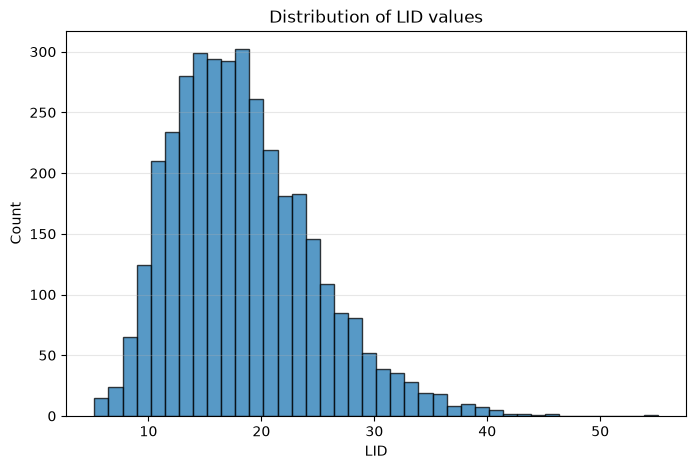

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df.LID, bins=40, edgecolor="black", alpha=0.75)
plt.title("Distribution of LID values")
plt.xlabel("LID")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [6]:
# Tesztelési alapadatok
query_pool = 500
k = 10
ef_search = 40

# Teszt halmaz létrehozása
rng = np.random
indices = rng.choice(len(df), size=query_pool, replace=False)
queries = [df.vector.iloc[i] for i in indices]


# HNSW_benchmark teszt futás - Random beszúrással
print("-------------------------------------------")
print("HNSW benchmark - Random order")
bm_normal = hnswbm.HNSW_benchmark(data=df.vector)

recalls_normal = bm_normal.run_multiple(queries, k=k, ef_search=ef_search, stats=True)


# HNSW_benchmark teszt futás - LID szerint csökkenő sorrendben való beszúrással
print("-------------------------------------------")
print("HNSW benchmark - LID descending order")
df_lid_desc_index = np.argsort(df.LID, descending=True)
df_lid_desc = [df.vector[i] for i in df_lid_desc_index]
bm_lid_desc = hnswbm.HNSW_benchmark(data=df_lid_desc)

recalls_lid_desc = bm_lid_desc.run_multiple(queries, k=k, ef_search=ef_search, stats=True)


# HNSW_benchmark teszt futás - LID szerint növekvő sorrendben való beszúrással
print("-------------------------------------------")
print("HNSW benchmark - LID ascending order")
df_lid_asc_index = np.argsort(df.LID, descending=False)
df_lid_asc = [df.vector[i] for i in df_lid_asc_index]
bm_lid_asc = hnswbm.HNSW_benchmark(data=df_lid_asc)

recalls_lid_asc = bm_lid_asc.run_multiple(queries, k=k, ef_search=ef_search, stats=True)

-------------------------------------------
HNSW benchmark - Random order
Minimum recall: 0.8000
Average recall: 0.9920
Maximum recall: 1.0000
Total time: 133.217 seconds
Average time per query: 266.434 ms
-------------------------------------------
HNSW benchmark - LID descending order
Minimum recall: 0.6000
Average recall: 0.9920
Maximum recall: 1.0000
Total time: 135.071 seconds
Average time per query: 270.141 ms
-------------------------------------------
HNSW benchmark - LID ascending order
Minimum recall: 0.7000
Average recall: 0.9914
Maximum recall: 1.0000
Total time: 135.595 seconds
Average time per query: 271.191 ms
